## Surveillance Anomaly Detection


In [1]:
!pip install torch torchvision torchaudio

In [2]:
import torch

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

Using device: mps


In [3]:
import torch
print(torch.backends.mps.is_available())

True


## Frame Feature Extraction using ResNet

This step converts raw video frames into compact feature vectors using a pretrained **ResNet CNN**.

Instead of training directly on images, each frame is passed through ResNet to extract a **2048-dimensional feature representation**. These features capture important visual patterns while reducing data size.

Pipeline:

Frames → Dataset → DataLoader → ResNet → Feature Vectors (2048)

The extracted features are later used to build temporal sequences for **anomaly detection**.

In [4]:
import os
import glob
import numpy as np
import torch
from PIL import Image
from torch.utils.data import Dataset, DataLoader

# ===============================
# Dataset Class
# ===============================
class FrameDataset(Dataset):
    def __init__(self, folder_path):
        self.image_paths = sorted(glob.glob(os.path.join(folder_path, "*.jpg")))

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        return transform(img)

# ===============================
# Feature Extraction Function
# ===============================
def extract_features_from_folder(folder_path, batch_size=128):

    dataset = FrameDataset(folder_path)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    features = []
    total_batches = len(loader)

    print(f"\nExtracting from: {folder_path}")
    print(f"Total images: {len(dataset)} | Batch size: {batch_size}")

    with torch.no_grad():
        for i, batch in enumerate(loader):
            batch = batch.to(device)

            output = resnet(batch)
            output = output.view(output.size(0), -1)  # (B, 2048)

            features.append(output.cpu().numpy())

            progress = (i + 1) / total_batches * 100
            print(f"Progress: {progress:.2f}%", end="\r")

    print("\nDone.")
    return np.concatenate(features, axis=0)

## Train & Validation Feature Extraction

Frames from each shard in the Train and Validation folders are passed through a pretrained **ResNet** to extract **2048-dimensional features**.  
The extracted features are concatenated to form `train_features` and `val_features`, which are later used for anomaly detection training.

In [12]:
TRAIN_ROOT = "Train"
VAL_ROOT = "Validation"

train_features_all = []
val_features_all = []

# -----------------------------
# TRAIN
# -----------------------------
print("\nStarting TRAIN feature extraction...\n")

train_shards = sorted(os.listdir(TRAIN_ROOT))

for idx, folder in enumerate(train_shards):
    full_path = os.path.join(TRAIN_ROOT, folder)
    
    if os.path.isdir(full_path):
        print(f"\nShard {idx+1}/{len(train_shards)}")
        feats = extract_features_from_folder(full_path, batch_size=128)
        train_features_all.append(feats)

train_features = np.concatenate(train_features_all, axis=0)

print("\nTrain features shape:", train_features.shape)


# -----------------------------
# VALIDATION
# -----------------------------
print("\nStarting VALIDATION feature extraction...\n")

val_shards = sorted(os.listdir(VAL_ROOT))

for idx, folder in enumerate(val_shards):
    full_path = os.path.join(VAL_ROOT, folder)
    
    if os.path.isdir(full_path):
        print(f"\nShard {idx+1}/{len(val_shards)}")
        feats = extract_features_from_folder(full_path, batch_size=128)
        val_features_all.append(feats)

val_features = np.concatenate(val_features_all, axis=0)

print("\nValidation features shape:", val_features.shape)

print("\n🎉 Feature extraction completed!")


Starting TRAIN feature extraction...


Shard 2/90

Extracting from: Train/frames-000000
Total images: 10000 | Batch size: 128
Progress: 100.00%
Done.

Shard 3/90

Extracting from: Train/frames-000001
Total images: 10000 | Batch size: 128
Progress: 100.00%
Done.

Shard 4/90

Extracting from: Train/frames-000002
Total images: 10000 | Batch size: 128
Progress: 100.00%
Done.

Shard 5/90

Extracting from: Train/frames-000003
Total images: 10000 | Batch size: 128
Progress: 100.00%
Done.

Shard 6/90

Extracting from: Train/frames-000004
Total images: 10000 | Batch size: 128
Progress: 100.00%
Done.

Shard 7/90

Extracting from: Train/frames-000005
Total images: 10000 | Batch size: 128
Progress: 100.00%
Done.

Shard 8/90

Extracting from: Train/frames-000006
Total images: 10000 | Batch size: 128
Progress: 100.00%
Done.

Shard 9/90

Extracting from: Train/frames-000007
Total images: 10000 | Batch size: 128
Progress: 100.00%
Done.

Shard 10/90

Extracting from: Train/frames-000008
Total images: 

In [6]:
import os
import numpy as np

os.makedirs("saved_features", exist_ok=True)

## Saving Extracted Features

The extracted frame features are saved to disk using NumPy.  
This avoids recomputing ResNet features every time the model is trained and significantly speeds up experimentation.

In [7]:
np.save("saved_features/train_features_full.npy", train_features)

print("✅ Train features saved.")
print("Size (GB):", train_features.nbytes / (1024**3))

NameError: name 'train_features' is not defined

## Saving Validation Features

The extracted features from the validation dataset are saved to disk as a `.npy` file.  
This allows the validation data to be reused during model evaluation without repeating the feature extraction step.

In [15]:
np.save("saved_features/val_features_full.npy", val_features)

print("✅ Validation features saved.")
print("Size (GB):", val_features.nbytes / (1024**3))

✅ Validation features saved.
Size (GB): 2.288818359375


In [8]:
import numpy as np

print("Loading saved features...\n")

train_features = np.load("saved_features/train_features_full.npy")
val_features = np.load("saved_features/val_features_full.npy")

print("Train features shape:", train_features.shape)
print("Validation features shape:", val_features.shape)

print("\n✅ Features loaded successfully!")

Loading saved features...

Train features shape: (862346, 2048)
Validation features shape: (300000, 2048)

✅ Features loaded successfully!


In [10]:
import numpy as np

train_features = np.load("saved_features/train_features_full.npy")
val_features = np.load("saved_features/val_features_full.npy")

print("Loaded:", train_features.shape, val_features.shape)

Loaded: (862346, 2048) (300000, 2048)


normalize train data only

In [9]:
train_mean = train_features.mean(axis=0)
train_std = train_features.std(axis=0) + 1e-8

train_features = (train_features - train_mean) / train_std
val_features = (val_features - train_mean) / train_std

print("Normalization done")

Normalization done


## Dynamic Sequence Dataset create

In [11]:
import torch
from torch.utils.data import Dataset

class DynamicSequenceDataset(Dataset):
    def __init__(self, features, seq_len=16, stride=5):
        self.features = features
        self.seq_len = seq_len
        self.stride = stride
        self.length = (len(features) - seq_len) // stride

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        start = idx * self.stride
        seq = self.features[start:start+self.seq_len]
        return torch.tensor(seq, dtype=torch.float32)

## Create Datasets

In [12]:
SEQ_LEN = 16
STRIDE = 5
BATCH_SIZE = 32

train_dataset = DynamicSequenceDataset(train_features, SEQ_LEN, STRIDE)
val_dataset = DynamicSequenceDataset(val_features, SEQ_LEN, STRIDE)

print("Train sequences:", len(train_dataset))
print("Val sequences:", len(val_dataset))

Train sequences: 172466
Val sequences: 59996


## Creating DataLoaders

DataLoaders are used to efficiently load data in batches during training and validation.

- **train_loader** loads training sequences with shuffling to improve model learning.
- **val_loader** loads validation sequences without shuffling to maintain the original order for evaluation.

Batch processing helps speed up training and allows the model to process multiple sequences at once.

In [13]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

## LSTM Autoencoder for Temporal Anomaly Detection(this is just for experimentation purpose not final modal)


In [14]:
import torch.nn as nn

class LSTMAutoencoder(nn.Module):
    def __init__(self, input_dim=2048, hidden_dim=512):
        super().__init__()

        self.encoder = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.decoder = nn.LSTM(hidden_dim, input_dim, batch_first=True)

    def forward(self, x):
        encoded, _ = self.encoder(x)
        decoded, _ = self.decoder(encoded)
        return decoded

# TRAINING SETUP

In [15]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

model = LSTMAutoencoder().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

## Training Loop (With Validation Loss)

In [ ]:
# EPOCHS = 15

# for epoch in range(EPOCHS):

#     model.train()
#     train_loss = 0

#     for batch in train_loader:
#         batch = batch.to(device)

#         output = model(batch)
#         loss = criterion(output, batch)

#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()

#         train_loss += loss.item()

#     train_loss /= len(train_loader)

#     # Validation
#     model.eval()
#     val_loss = 0

#     with torch.no_grad():
#         for batch in val_loader:
#             batch = batch.to(device)
#             output = model(batch)
#             loss = criterion(output, batch)
#             val_loss += loss.item()

#     val_loss /= len(val_loader)

#     print(f"Epoch {epoch+1}/{EPOCHS} || "
#           f"Train Loss: {train_loss:.6f} || "
#           f"Validation Loss: {val_loss:.6f}")

KeyboardInterrupt: 

In [ ]:
# EPOCHS = 15

# for epoch in range(EPOCHS):

#     print(f"\n==============================")
#     print(f"🚀 Starting Epoch {epoch+1}/{EPOCHS}")
#     print(f"==============================")

#     # ======================
#     # TRAIN
#     # ======================
#     model.train()
#     train_loss = 0

#     for batch in train_loader:
#         batch = batch.to(device)

#         output = model(batch)
#         loss = criterion(output, batch)

#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()

#         train_loss += loss.item()

#     train_loss /= len(train_loader)

#     # ======================
#     # VALIDATION
#     # ======================
#     model.eval()
#     val_loss = 0

#     with torch.no_grad():
#         for batch in val_loader:
#             batch = batch.to(device)
#             output = model(batch)
#             loss = criterion(output, batch)
#             val_loss += loss.item()

#     val_loss /= len(val_loader)

#     print(f"✅ Epoch {epoch+1}/{EPOCHS} Completed")
#     print(f"Train Loss: {train_loss:.6f}")
#     print(f"Validation Loss: {val_loss:.6f}")


🚀 Starting Epoch 1/15
✅ Epoch 1/15 Completed
Train Loss: 0.265255
Validation Loss: 0.454019

🚀 Starting Epoch 2/15
✅ Epoch 2/15 Completed
Train Loss: 0.263416
Validation Loss: 0.457532

🚀 Starting Epoch 3/15
✅ Epoch 3/15 Completed
Train Loss: 0.262107
Validation Loss: 0.452415

🚀 Starting Epoch 4/15
✅ Epoch 4/15 Completed
Train Loss: 0.261435
Validation Loss: 0.450164

🚀 Starting Epoch 5/15
✅ Epoch 5/15 Completed
Train Loss: 0.261181
Validation Loss: 0.450156

🚀 Starting Epoch 6/15
✅ Epoch 6/15 Completed
Train Loss: 0.261197
Validation Loss: 0.450052

🚀 Starting Epoch 7/15
✅ Epoch 7/15 Completed
Train Loss: 0.260908
Validation Loss: 0.450035

🚀 Starting Epoch 8/15
✅ Epoch 8/15 Completed
Train Loss: 0.273504
Validation Loss: 0.480323

🚀 Starting Epoch 9/15
✅ Epoch 9/15 Completed
Train Loss: 0.285663
Validation Loss: 0.515314

🚀 Starting Epoch 10/15
✅ Epoch 10/15 Completed
Train Loss: 0.319265
Validation Loss: 0.559598

🚀 Starting Epoch 11/15
✅ Epoch 11/15 Completed
Train Loss: 0.345949

## This is showoing training instability as both losses are getting increase after epochs 6-7


experiment try with  change of  learning rate

In [ ]:
# # Optimizer
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# # Scheduler (without verbose)
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
#     optimizer,
#     mode='min',
#     patience=2,
#     factor=0.5
# )

# criterion = torch.nn.MSELoss()

# EPOCHS = 10
# best_val_loss = float("inf")
# early_stop_counter = 0
# early_stop_patience = 3

again training with updating learning rates & optimizers

In [ ]:
# for epoch in range(EPOCHS):

#     print("\n==============================")
#     print(f"🚀 Starting Epoch {epoch+1}/{EPOCHS}")
#     print("==============================")

#     # TRAIN
#     model.train()
#     train_loss = 0

#     for batch in train_loader:
#         batch = batch.to(device)

#         optimizer.zero_grad()
#         output = model(batch)
#         loss = criterion(output, batch)

#         loss.backward()
#         torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
#         optimizer.step()

#         train_loss += loss.item()

#     train_loss /= len(train_loader)

#     # VALIDATION
#     model.eval()
#     val_loss = 0

#     with torch.no_grad():
#         for batch in val_loader:
#             batch = batch.to(device)
#             output = model(batch)
#             loss = criterion(output, batch)
#             val_loss += loss.item()

#     val_loss /= len(val_loader)

#     # Step scheduler
#     scheduler.step(val_loss)

#     # Save best model
#     if val_loss < best_val_loss:
#         best_val_loss = val_loss
#         torch.save(model.state_dict(), "best_model.pth")
#         early_stop_counter = 0
#         print("✅ Best model saved.")
#     else:
#         early_stop_counter += 1

#     print(f"✅ Epoch {epoch+1}/{EPOCHS} Completed")
#     print(f"Train Loss: {train_loss:.6f}")
#     print(f"Validation Loss: {val_loss:.6f}")
#     print(f"Learning Rate: {optimizer.param_groups[0]['lr']:.6f}")

#     if early_stop_counter >= early_stop_patience:
#         print("⛔ Early stopping triggered.")
#         break


🚀 Starting Epoch 1/10
✅ Best model saved.
✅ Epoch 1/10 Completed
Train Loss: 0.356571
Validation Loss: 0.587816
Learning Rate: 0.001000

🚀 Starting Epoch 2/10
✅ Epoch 2/10 Completed
Train Loss: 0.361376
Validation Loss: 0.591724
Learning Rate: 0.001000

🚀 Starting Epoch 3/10
✅ Epoch 3/10 Completed
Train Loss: 0.359399
Validation Loss: 0.589857
Learning Rate: 0.001000

🚀 Starting Epoch 4/10


KeyboardInterrupt: 

 ## LSTM Autoencoder Experiment

An LSTM Autoencoder was initially evaluated to model temporal dependencies between frame features. However, during training it showed unstable behavior, with both training and validation losses increasing after several epochs. This indicated difficulty in learning stable representations for high-dimensional visual features.

To address this, a Transformer-based Autoencoder was adopted. Transformers use self-attention to capture global temporal relationships and handle high-dimensional feature representations more effectively. This resulted in more stable training and improved anomaly detection performance.

# transformers auto encoder adopted for training 

Input:  (batch, 16, 2048)
↓
Linear projection → 512
↓
Transformer Encoder (self-attention)
↓
Decoder (MLP)
↓
Reconstruct 2048

 ResNet → Sequence → Transformer Autoencoder → Reconstruction Error → Anomaly Score

In [ ]:
# import torch
# import torch.nn as nn
# import math

# class PositionalEncoding(nn.Module):
#     def __init__(self, d_model, max_len=100):
#         super().__init__()

#         pe = torch.zeros(max_len, d_model)
#         position = torch.arange(0, max_len).unsqueeze(1)

#         div_term = torch.exp(
#             torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model)
#         )

#         pe[:, 0::2] = torch.sin(position * div_term)
#         pe[:, 1::2] = torch.cos(position * div_term)

#         pe = pe.unsqueeze(0)  # (1, max_len, d_model)
#         self.register_buffer('pe', pe)

#     def forward(self, x):
#         x = x + self.pe[:, :x.size(1)]
#         return x


# class TransformerAutoencoder(nn.Module):
#     def __init__(self,
#                  input_dim=2048,
#                  model_dim=512,
#                  num_heads=8,
#                  num_layers=3,
#                  dropout=0.1):

#         super().__init__()

#         # Project 2048 → 512
#         self.input_projection = nn.Linear(input_dim, model_dim)

#         # Positional Encoding
#         self.pos_encoder = PositionalEncoding(model_dim)

#         # Transformer Encoder
#         encoder_layer = nn.TransformerEncoderLayer(
#             d_model=model_dim,
#             nhead=num_heads,
#             dim_feedforward=1024,
#             dropout=dropout,
#             batch_first=True
#         )

#         self.transformer_encoder = nn.TransformerEncoder(
#             encoder_layer,
#             num_layers=num_layers
#         )

#         # Decoder (512 → 2048)
#         self.decoder = nn.Sequential(
#             nn.Linear(model_dim, 1024),
#             nn.ReLU(),
#             nn.Linear(1024, input_dim)
#         )

#     def forward(self, x):
#         # x shape: (batch, seq_len, 2048)

#         x = self.input_projection(x)      # (batch, seq_len, 512)
#         x = self.pos_encoder(x)           # add positional encoding
#         encoded = self.transformer_encoder(x)

#         reconstructed = self.decoder(encoded)

#         return reconstructed

In [ ]:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# model = TransformerAutoencoder(
#     input_dim=2048,
#     model_dim=512,
#     num_heads=8,
#     num_layers=3
# ).to(device)

# print("Model initialized.")

Model initialized.


In [ ]:
# criterion = nn.MSELoss()

# optimizer = torch.optim.Adam(
#     model.parameters(),
#     lr=3e-4,              # smaller than LSTM
#     weight_decay=1e-5     # prevent overfitting
# )

In [ ]:
# EPOCHS = 10
# best_val_loss = float("inf")

# for epoch in range(EPOCHS):

#     print(f"\n==============================")
#     print(f"🚀 Starting Epoch {epoch+1}/{EPOCHS}")
#     print(f"==============================")

#     # ------------------
#     # TRAIN
#     # ------------------
#     model.train()
#     train_loss = 0

#     for batch in train_loader:
#         batch = batch.to(device)

#         output = model(batch)
#         loss = criterion(output, batch)

#         optimizer.zero_grad()
#         loss.backward()
#         torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
#         optimizer.step()

#         train_loss += loss.item()

#     train_loss /= len(train_loader)

#     # ------------------
#     # VALIDATION
#     # ------------------
#     model.eval()
#     val_loss = 0

#     with torch.no_grad():
#         for batch in val_loader:
#             batch = batch.to(device)
#             output = model(batch)
#             loss = criterion(output, batch)
#             val_loss += loss.item()

#     val_loss /= len(val_loader)

#     # Save best model
#     if val_loss < best_val_loss:
#         best_val_loss = val_loss
#         torch.save(model.state_dict(), "best_transformer_model.pth")
#         print("✅ Best model saved.")

#     print(f"✅ Epoch {epoch+1}/{EPOCHS} Completed")
#     print(f"Train Loss: {train_loss:.6f}")
#     print(f"Validation Loss: {val_loss:.6f}")


🚀 Starting Epoch 1/10
✅ Best model saved.
✅ Epoch 1/10 Completed
Train Loss: 0.090733
Validation Loss: 0.111490

🚀 Starting Epoch 2/10
✅ Best model saved.
✅ Epoch 2/10 Completed
Train Loss: 0.042298
Validation Loss: 0.088035

🚀 Starting Epoch 3/10
✅ Best model saved.
✅ Epoch 3/10 Completed
Train Loss: 0.035555
Validation Loss: 0.079991

🚀 Starting Epoch 4/10
✅ Best model saved.
✅ Epoch 4/10 Completed
Train Loss: 0.032130
Validation Loss: 0.077224

🚀 Starting Epoch 5/10
✅ Best model saved.
✅ Epoch 5/10 Completed
Train Loss: 0.030373
Validation Loss: 0.074864

🚀 Starting Epoch 6/10
✅ Best model saved.
✅ Epoch 6/10 Completed
Train Loss: 0.029332
Validation Loss: 0.070670

🚀 Starting Epoch 7/10
✅ Best model saved.
✅ Epoch 7/10 Completed
Train Loss: 0.028801
Validation Loss: 0.070164

🚀 Starting Epoch 8/10
✅ Best model saved.
✅ Epoch 8/10 Completed
Train Loss: 0.028340
Validation Loss: 0.067929

🚀 Starting Epoch 9/10
✅ Epoch 9/10 Completed
Train Loss: 0.028121
Validation Loss: 0.069201

🚀 

In [ ]:
# model = TransformerAutoencoder().to(device)
# model.load_state_dict(torch.load("best_transformer_model.pth"))
# model.eval()

# print("✅ Best Transformer model loaded.")

✅ Best Transformer model loaded.


Compute Reconstruction Errors (Train + Validation)

In [ ]:
# import numpy as np

# def get_reconstruction_errors(loader, model):
#     errors = []
#     model.eval()

#     with torch.no_grad():
#         for batch in loader:
#             batch = batch.to(device)
#             output = model(batch)

#             # MSE per sequence
#             loss = torch.mean((batch - output) ** 2, dim=(1,2))
#             errors.extend(loss.cpu().numpy())

#     return np.array(errors)


# print("Computing train reconstruction errors...")
# train_errors = get_reconstruction_errors(train_loader, model)

# print("Computing validation reconstruction errors...")
# val_errors = get_reconstruction_errors(val_loader, model)

# print("Train Mean:", train_errors.mean())
# print("Train Std:", train_errors.std())
# print("Validation Mean:", val_errors.mean())
# print("Validation Std:", val_errors.std())

Computing train reconstruction errors...
Computing validation reconstruction errors...
Train Mean: 0.0274142
Train Std: 0.030719934
Validation Mean: 0.06792999
Validation Std: 0.04892516


### Reconstruction Error Threshold

Reconstruction errors were computed for training sequences to estimate the distribution of normal behaviour.  

The anomaly threshold was calculated using statistical deviation:

- **2σ threshold = mean + 2 × std**
- **3σ threshold = mean + 3 × std**

Sequences with reconstruction error greater than the threshold are classified as anomalies.

In [ ]:
# threshold_2sigma = train_errors.mean() + 2 * train_errors.std()
# threshold_3sigma = train_errors.mean() + 3 * train_errors.std()

# print("2σ Threshold:", threshold_2sigma)
# print("3σ Threshold:", threshold_3sigma)

2σ Threshold: 0.08885407
3σ Threshold: 0.119574


count validation anamolies

In [ ]:
# val_anomalies_2sigma = np.sum(val_errors > threshold_2sigma)
# val_anomalies_3sigma = np.sum(val_errors > threshold_3sigma)

# print("Validation sequences:", len(val_errors))
# print("Above 2σ:", val_anomalies_2sigma)
# print("Above 3σ:", val_anomalies_3sigma)

Validation sequences: 59996
Above 2σ: 6397
Above 3σ: 3738


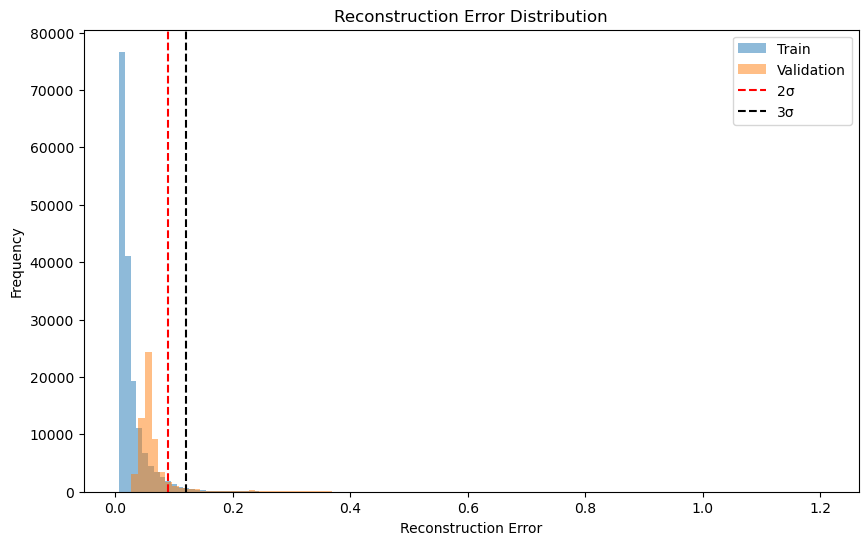

In [ ]:
# import matplotlib.pyplot as plt

# plt.figure(figsize=(10,6))
# plt.hist(train_errors, bins=100, alpha=0.5, label="Train")
# plt.hist(val_errors, bins=100, alpha=0.5, label="Validation")

# plt.axvline(threshold_2sigma, color='red', linestyle='--', label="2σ")
# plt.axvline(threshold_3sigma, color='black', linestyle='--', label="3σ")

# plt.legend()
# plt.title("Reconstruction Error Distribution")
# plt.xlabel("Reconstruction Error")
# plt.ylabel("Frequency")
# plt.show()

In [ ]:
# import pandas as pd
# import numpy as np

# # Load index file (contains all frames info)
# index_df = pd.read_csv("/Users/ssweeti/Desktop/Anamoly_detection/Test/index_test.csv")

# # Load anomaly labels
# labels_df = pd.read_csv("/Users/ssweeti/Desktop/Anamoly_detection/Test/anomaly-labels.csv")

# # Remove -1 labels (ignore tracking mistakes)
# labels_df = labels_df[labels_df["label"] != -1]

# print("Total frames in index:", len(index_df))
# print("Total real anomaly intervals:", len(labels_df))

Total frames in index: 1724714
Total real anomaly intervals: 302


In [ ]:
# validation_shards = [
# "frames-000008.tar","frames-000041.tar","frames-000099.tar","frames-000023.tar",
# "frames-000148.tar","frames-000050.tar","frames-000131.tar","frames-000014.tar",
# "frames-000163.tar","frames-000034.tar","frames-000002.tar","frames-000070.tar",
# "frames-000156.tar","frames-000013.tar","frames-000083.tar","frames-000064.tar",
# "frames-000091.tar","frames-000040.tar","frames-000075.tar","frames-000129.tar",
# "frames-000030.tar","frames-000087.tar","frames-000071.tar","frames-000096.tar",
# "frames-000003.tar","frames-000078.tar","frames-000069.tar","frames-000090.tar",
# "frames-000082.tar","frames-000074.tar"
# ]

# val_index_df = index_df[index_df["shard"].isin(validation_shards)].copy()

# print("Validation frames:", len(val_index_df))

Validation frames: 300000


In [ ]:
# # Initialize all as normal
# val_index_df["gt"] = 0

# # Mark anomaly frames
# for _, row in labels_df.iterrows():
#     start = row["start_timestamp"]
#     end = row["end_timestamp"]

#     mask = (
#         (val_index_df["timestamp_utc_ms"] >= start) &
#         (val_index_df["timestamp_utc_ms"] <= end)
#     )

#     val_index_df.loc[mask, "gt"] = 1

# print("Total anomaly frames in validation:", val_index_df["gt"].sum())

Total anomaly frames in validation: 13308


In [ ]:
# window_size = 16
# stride = 5

# frame_labels = val_index_df["gt"].values

# sequence_labels = []

# for i in range(0, len(frame_labels) - window_size, stride):
#     window = frame_labels[i:i+window_size]

#     if np.any(window == 1):
#         sequence_labels.append(1)
#     else:
#         sequence_labels.append(0)

# sequence_labels = np.array(sequence_labels)

# print("Labels length:", len(sequence_labels))
# print("Errors length:", len(val_errors))

Labels length: 59997
Errors length: 59996


In [ ]:
# import torch

# model.eval()

# val_errors = []

# with torch.no_grad():
#     for batch in val_loader:
#         batch = batch.to(device)
#         output = model(batch)

#         loss = torch.mean((output - batch)**2, dim=(1,2))
#         val_errors.extend(loss.cpu().numpy())

# val_errors = np.array(val_errors)

# print("Validation errors shape:", val_errors.shape)

Validation errors shape: (59996,)


In [ ]:
# sequence_labels = sequence_labels[:len(val_errors)]

# print("Labels length:", len(sequence_labels))
# print("Errors length:", len(val_errors))

Labels length: 59996
Errors length: 59996


## compute validation AUC(window_size=16,stride=5) 

plot AUC-ROC curve

In [ ]:
# import pandas as pd

# # Load files
# index_df = pd.read_csv("/Users/ssweeti/Desktop/Anamoly_detection/Test/index_test.csv")
# labels_df = pd.read_csv("/Users/ssweeti/Desktop/Anamoly_detection/Test/anomaly-labels.csv")

# # Remove -1 labels
# labels_df = labels_df[labels_df["label"] != -1]

# # All shards present in test index
# all_test_shards = set(index_df["shard"].unique())

# # Shards that contain real anomalies
# anomaly_shards = set(
#     index_df[index_df["timestamp_utc_ms"].isin(
#         labels_df["start_timestamp"].values
#     )]["shard"]
# )

# print("Total test shards:", len(all_test_shards))
# print("Shards with real anomalies:", len(anomaly_shards))

# # Shards with NO real anomalies
# normal_shards = sorted(all_test_shards - anomaly_shards)

# print("Pure normal shards (no real anomaly labels):")
# for s in normal_shards:
#     print(s)

# print("Total pure normal shards:", len(normal_shards))

Total test shards: 173
Shards with real anomalies: 119
Pure normal shards (no real anomaly labels):
frames-000001.tar
frames-000002.tar
frames-000003.tar
frames-000004.tar
frames-000007.tar
frames-000013.tar
frames-000030.tar
frames-000036.tar
frames-000040.tar
frames-000063.tar
frames-000064.tar
frames-000066.tar
frames-000069.tar
frames-000070.tar
frames-000071.tar
frames-000072.tar
frames-000073.tar
frames-000074.tar
frames-000075.tar
frames-000076.tar
frames-000077.tar
frames-000078.tar
frames-000079.tar
frames-000080.tar
frames-000082.tar
frames-000083.tar
frames-000084.tar
frames-000086.tar
frames-000087.tar
frames-000088.tar
frames-000090.tar
frames-000091.tar
frames-000092.tar
frames-000093.tar
frames-000095.tar
frames-000096.tar
frames-000097.tar
frames-000102.tar
frames-000105.tar
frames-000129.tar
frames-000156.tar
frames-000157.tar
frames-000159.tar
frames-000160.tar
frames-000161.tar
frames-000163.tar
frames-000164.tar
frames-000165.tar
frames-000166.tar
frames-000167.tar


TEST FEATURES EXTRACTION

In [55]:
import torch

if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("🚀 Using Apple GPU (MPS)")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("🚀 Using CUDA GPU")
else:
    device = torch.device("cpu")
    print("⚠ Using CPU")

print("Device:", device)

🚀 Using Apple GPU (MPS)
Device: mps


resnet load

In [56]:
import torchvision.models as models

resnet = models.resnet50(weights="IMAGENET1K_V1")
resnet = torch.nn.Sequential(*list(resnet.children())[:-1])
resnet = resnet.to(device)
resnet.eval()

print("✅ ResNet loaded on", device)

✅ ResNet loaded on mps


In [57]:
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

 Test features Extraction (GPU + Stride=5)

In [58]:
import os
import glob
import numpy as np
from PIL import Image
from tqdm import tqdm

def extract_features_from_folder(folder_path, batch_size=128):
    image_paths = sorted(glob.glob(os.path.join(folder_path, "*.jpg")))
    features = []

    print(f"\nExtracting from: {folder_path}")
    print(f"Total images: {len(image_paths)} | Batch size: {batch_size}")

    with torch.no_grad():
        for i in tqdm(range(0, len(image_paths), batch_size)):
            batch_paths = image_paths[i:i+batch_size]
            batch_images = []

            for img_path in batch_paths:
                img = Image.open(img_path).convert("RGB")
                img = transform(img)
                batch_images.append(img)

            batch_images = torch.stack(batch_images).to(device)

            batch_features = resnet(batch_images)
            batch_features = batch_features.view(batch_features.size(0), -1)

            features.append(batch_features.cpu().numpy())

    return np.concatenate(features, axis=0)

In [98]:
TEST_ROOT = "Test"

test_features_all = []

print("🚀 Starting FULL TEST feature extraction...\n")

for folder in sorted(os.listdir(TEST_ROOT)):
    full_path = os.path.join(TEST_ROOT, folder)

    # Skip CSV files
    if os.path.isdir(full_path):
        feats = extract_features_from_folder(full_path, batch_size=128)
        test_features_all.append(feats)

test_features = np.concatenate(test_features_all, axis=0)

print("\n✅ Test features shape:", test_features.shape)

🚀 Starting FULL TEST feature extraction...


Extracting from: Test/frames-000000
Total images: 10000 | Batch size: 128


100%|██████████| 79/79 [00:43<00:00,  1.82it/s]



Extracting from: Test/frames-000001
Total images: 10000 | Batch size: 128


100%|██████████| 79/79 [00:40<00:00,  1.97it/s]



Extracting from: Test/frames-000004
Total images: 10000 | Batch size: 128


...


Extracting from: Test/frames-000160
Total images: 10000 | Batch size: 128


100%|██████████| 79/79 [00:39<00:00,  1.99it/s]



Extracting from: Test/frames-000172
Total images: 4714 | Batch size: 128


100%|██████████| 37/37 [00:20<00:00,  1.77it/s]



✅ Test features shape: (384714, 2048)


save the test features for reuse in diffrent experiments

In [59]:
os.makedirs("saved_features", exist_ok=True)

np.save("saved_features/test_features_full.npy", test_features)

print("✅ Test features saved.")
print("Size (GB):", test_features.nbytes / (1024**3))

✅ Test features saved.
Size (GB): 2.9351348876953125


load & normalize

In [60]:
import numpy as np

# Load
test_features = np.load("saved_features/test_features_full.npy")

# Normalize using TRAIN stats
test_features = (test_features - train_mean) / train_std

print("Test features normalized:", test_features.shape)

Test features normalized: (384714, 2048)


In [62]:
import torch
from torch.utils.data import DataLoader, TensorDataset

test_tensor = torch.tensor(test_sequences, dtype=torch.float32)
test_dataset = TensorDataset(test_tensor)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

compute reconstruction error(move model to gpu as features have been passed through it)

In [63]:
model = model.to(device)
model.eval()

print("Model moved to:", next(model.parameters()).device)

Model moved to: mps:0


labels assign check

In [154]:
!pip install opencv-python

refer this file only for feature extractions->> models have been trained in (surveillance_anomaly_detection.ipynb)